In [41]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
%matplotlib inline

In [42]:
# import the dataset
from sklearn.datasets import make_blobs


In [43]:
x,y=make_blobs(n_samples=1000,centers=3,n_features=2)
# it is going to make a dataset andthen divide it in 2 columns x and y
# hamara model x pr kam krega y pr bs check krega ki kya prdiction thik hai ki nahi

#centres=3 means ki 3 clusters bnenge
#n_feaures=2 mtlb do features honge
# aur 1000 rows hongi

In [44]:
x

array([[-4.00237167,  2.61073761],
       [ 5.98889031, -0.48167927],
       [-2.87964037,  4.65869759],
       ...,
       [-2.64133846,  3.15010105],
       [-1.20304411,  3.29684441],
       [-4.93636519,  2.83403488]])

In [45]:
y

array([0, 1, 0, 1, 0, 2, 2, 0, 1, 0, 1, 1, 0, 0, 2, 2, 2, 1, 1, 0, 0, 1,
       2, 2, 2, 0, 1, 2, 2, 2, 1, 1, 1, 2, 0, 2, 1, 1, 0, 0, 2, 2, 0, 1,
       0, 2, 1, 2, 1, 1, 2, 1, 2, 1, 0, 1, 1, 2, 1, 0, 1, 2, 1, 2, 2, 0,
       2, 2, 0, 1, 0, 0, 1, 1, 1, 2, 2, 1, 1, 0, 0, 2, 1, 2, 2, 0, 2, 2,
       0, 2, 1, 2, 1, 0, 1, 1, 2, 2, 0, 0, 0, 2, 2, 0, 1, 0, 0, 2, 0, 0,
       1, 0, 1, 0, 2, 1, 1, 1, 0, 2, 2, 2, 1, 2, 1, 1, 1, 0, 2, 0, 2, 0,
       2, 1, 2, 2, 0, 2, 0, 0, 1, 2, 0, 0, 1, 0, 1, 2, 0, 1, 2, 1, 2, 2,
       0, 0, 0, 0, 1, 0, 1, 2, 1, 0, 2, 2, 1, 1, 1, 2, 1, 2, 0, 0, 2, 0,
       1, 0, 1, 1, 2, 2, 1, 1, 2, 0, 2, 2, 0, 2, 2, 2, 2, 1, 0, 2, 1, 1,
       2, 0, 1, 1, 1, 2, 0, 2, 2, 2, 2, 1, 2, 0, 1, 0, 0, 0, 2, 1, 2, 1,
       0, 0, 0, 2, 0, 2, 0, 0, 2, 0, 0, 2, 0, 1, 2, 1, 1, 2, 2, 2, 2, 2,
       1, 1, 2, 2, 0, 0, 2, 0, 0, 1, 0, 2, 0, 1, 2, 1, 2, 2, 0, 2, 1, 1,
       2, 1, 2, 0, 0, 0, 1, 0, 0, 0, 1, 1, 2, 1, 2, 2, 2, 1, 1, 2, 1, 1,
       0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 2, 1,

# BUT IN REAL DATASET WE WILL NEVER KNOW HOW MANY CLUSTERS ARE THERE
- HENCE WE ARE GOING TO FIND NO OF FEATURES BY USING K MEANS AND VERIFY THEM FROM Y 

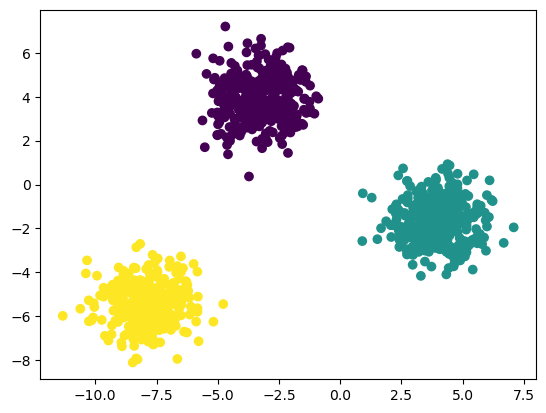

In [46]:
plt.scatter(x[:,0],x[:,1],c=y)
plt.show()

# NOW FINDING NO OF CLUSTERS NEEDED USING ELBOW TECHNIQUE

In [47]:
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()

In [48]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,random_state=42,test_size=0.3)

In [49]:
x_scaled=sc.fit_transform(x_train)
test_scaled=sc.transform(x_test) # prevent data leakage


In [50]:
from sklearn.cluster import KMeans


In [51]:
wcss=[]
for k in range(1,11):
    kmeans=KMeans(n_clusters=k,init='k-means++')
    kmeans.fit(x_scaled)
    wcss.append(kmeans.inertia_)

In [52]:
wcss

[1400.0000000000018,
 557.1924826006054,
 73.47151410668778,
 65.99306852823258,
 51.36894597475926,
 46.680394485982944,
 39.31109055166033,
 35.59589745521299,
 33.62207352045611,
 28.37459554348168]

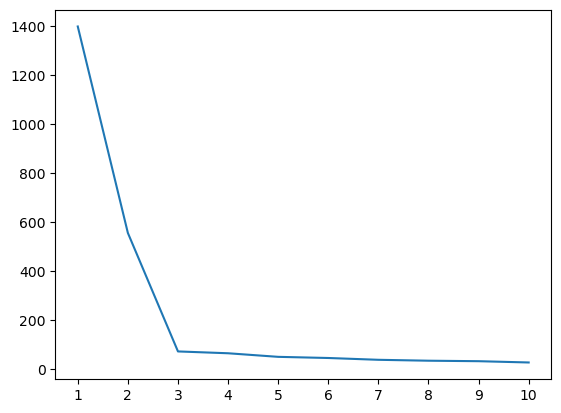

In [53]:

plt.plot(range(1,11),wcss)
plt.xticks(range(1,11))# isse har value k liye apki corresponding value plot hojayegi
plt.show()

In [ ]:
# hence dekho 3 tk giri iuske bad it got stabled !!!

kmeans=KMeans(n_clusters=3,init="k-means++")
kmeans.fit_predict(x_train)

array([2, 2, 2, 1, 0, 0, 1, 2, 0, 2, 2, 1, 2, 2, 1, 2, 1, 2, 2, 0, 2, 2,
       2, 1, 1, 2, 2, 1, 0, 0, 1, 0, 0, 2, 2, 2, 2, 0, 2, 1, 2, 0, 2, 0,
       0, 0, 2, 0, 0, 0, 1, 0, 1, 0, 2, 2, 0, 1, 2, 0, 0, 1, 1, 1, 1, 1,
       0, 0, 1, 1, 1, 1, 0, 2, 1, 1, 2, 0, 2, 1, 1, 2, 0, 1, 2, 2, 2, 1,
       2, 2, 2, 1, 0, 2, 0, 0, 2, 0, 2, 2, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1,
       1, 1, 0, 1, 1, 2, 1, 0, 1, 1, 0, 2, 2, 1, 2, 0, 1, 1, 2, 2, 0, 2,
       2, 2, 1, 2, 0, 2, 2, 0, 1, 1, 2, 2, 2, 0, 0, 0, 0, 0, 0, 0, 0, 2,
       1, 0, 2, 2, 2, 2, 0, 2, 0, 0, 1, 0, 1, 2, 0, 2, 2, 0, 1, 1, 2, 0,
       2, 2, 0, 2, 1, 0, 0, 1, 0, 0, 2, 2, 0, 0, 0, 1, 0, 2, 1, 0, 1, 1,
       1, 0, 1, 2, 1, 2, 2, 2, 2, 2, 2, 0, 0, 0, 2, 1, 1, 1, 2, 0, 1, 1,
       1, 1, 2, 1, 0, 0, 2, 1, 1, 2, 0, 2, 1, 0, 2, 1, 1, 1, 2, 2, 2, 2,
       0, 2, 0, 2, 1, 1, 0, 0, 0, 2, 0, 1, 1, 1, 0, 2, 0, 1, 1, 2, 2, 0,
       0, 2, 2, 0, 1, 0, 0, 0, 0, 1, 0, 1, 2, 2, 0, 1, 1, 2, 0, 0, 2, 1,
       2, 2, 2, 2, 1, 0, 0, 2, 1, 2, 0, 2, 1, 2, 0,

In [55]:
y_pred=kmeans.predict(test_scaled)

from sklearn.metrics import confusion_matrix
print(confusion_matrix(y_pred,y_test))

[[ 0 95 83]
 [ 0  0  0]
 [99  0 23]]


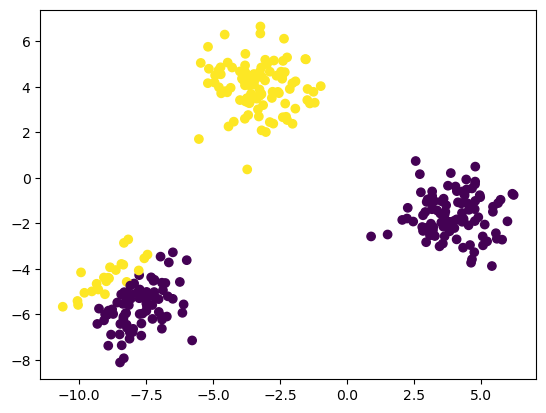

In [56]:
plt.scatter(x_test[:,0],x_test[:,1],c=y_pred)
plt.show()

In [57]:
# VALIDATING THE K VALUE DONE USING - 
# - KNEE LOCATER
# - SILHOUTEE SCORING

# KNEE LOCATOR

In [58]:
!pip install kneed

In [59]:
from kneed import KneeLocator

In [60]:
kl=KneeLocator(range(1,11),wcss,curve='convex',direction='decreasing')

In [61]:
kl.elbow

3

# SILHOUTTE SCORE

In [63]:
from sklearn.metrics import silhouette_score


In [64]:
silhouette_coefficients=[]
for k in range(2,11):
    kmeans=KMeans(n_clusters=k,init='k-means++')
    kmeans.fit(x_scaled)
    score=silhouette_score(x_scaled,kmeans.labels_)
    silhouette_coefficients.append(score)

In [65]:
print(silhouette_coefficients)

[0.6253074079722711, 0.8100617944665125, 0.6636756626946249, 0.5193878246704363, 0.4983708071768494, 0.35803367299099326, 0.34652109563462563, 0.34204016098870643, 0.3462287371755613]


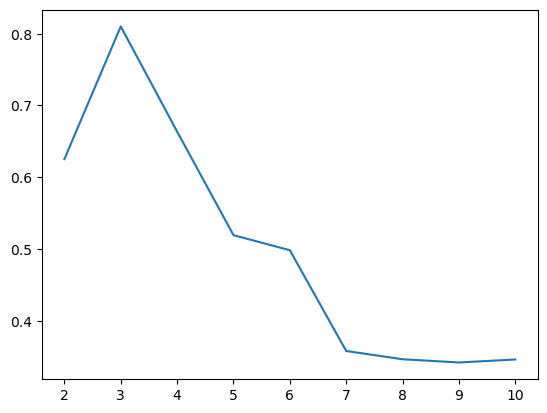

In [ ]:
plt.plot(range(2,11),silhouette_coefficients)
plt.xticks(range(2,11))
plt.show()

#at the value of k(no of needed centroids) the value was maximum